# Pareto Front Visualisation

For our PC-RGCN Model we have used Multi Objective Optimization to help speed up the process of drug discovery. The Process of Multi Objective Optimization requires several steps that must be performed sequentially which this juypter note will guide the reader through. For the purposes of demonstration we will be using PDBbind Dataset for this notebook.



## GridSearch


One of the first Steps we need to perform is to search for the phyiscs weights that will be used for training. Grid Search exhaustively searches every weight and finds the most accurate weights.


In [ ]:

import torch
import torch.optim as optim
import pandas as pd
import numpy as np
import sys
import os
import random
import time
import json
from datetime import timedelta, datetime
from torch.utils.data import Dataset, DataLoader


'''
Figure out how to have a relative os file system for other system
'''
sys.path.insert(0, '/home/exouser/git_test/multi-objective-pdbbind')
sys.path.insert(0, '/home/exouser/git_test/multi-objective-pdbbind/pdbbind')

from models.layers_pytorch_pdbbind import PGGCNModel
# Also removed hydrogen atoms from the dataset
from train_split_data import load_data_with_saved_split


The following Code Block is the configuration for grid search the important line to configure is the SUBSET_SIZE variable which will determine the size of the dataset that will be used for training.

In [ ]:

# ============================================================================
# CONFIG — change SUBSET_SIZE to switch dataset size
# ============================================================================

class Config:
    # -------------------------------------------------------------------------
    # CHANGE THIS to switch dataset size: 100, 250, 500, 1000, 1500, 2000, 2660
    SUBSET_SIZE = 100
    # -------------------------------------------------------------------------

    SUBSET_DIR = '/home/exouser/git_test/multi-objective-pdbbind/Datasets/subsets'
    CSV_PATH   = '/home/exouser/git_test/multi-objective-pdbbind/Datasets/pdbbind.csv'
    PKL_PATH   = '/home/exouser/git_test/multi-objective-pdbbind/Datasets/PDBBind_full.pkl'

    # Model architecture — matches train_subset.py
    NUM_ATOM_FEATURES = 36
    R_OUT_CHANNEL     = 20
    C_OUT_CHANNEL     = 1024
    DROPOUT_RATE      = 0.05   # tuned from sweep

    # Training hyperparameters — tuned from sweep
    EPOCHS      = 300
    BATCH_SIZE  = 8
    LEARNING_RATE = 5e-4
    L2_WEIGHT   = 1e-4
    MAX_NORM    = 3.0

    # Physics weights to search — 101 values from 0.0 to 1.0
    PHYSICS_WEIGHTS = np.arange(0.0, 1.01, 0.01)

    RANDOM_SEED = 50

    @property
    def split_path(self):
        return os.path.join(self.SUBSET_DIR, f'pdbbind_subset_{self.SUBSET_SIZE}.pkl')

    @property
    def save_dir(self):
        return (
            '/home/exouser/git_test/multi-objective-pdbbind/'
            f'pdbbind/grid_search/subset_{self.SUBSET_SIZE}'
        )



In [ ]:


# ============================================================================
# MAIN
# ============================================================================

def main():
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    config    = Config()

    print("=" * 80)
    print(f"GRID SEARCH: PHYSICS WEIGHT — Subset {config.SUBSET_SIZE}")
    print("=" * 80)
    print(f"Timestamp:      {timestamp}")
    print(f"Subset size:    {config.SUBSET_SIZE}")
    print(f"Weights to test: {len(config.PHYSICS_WEIGHTS)} (0.0 → 1.0)")
    print(f"Epochs per run:  {config.EPOCHS}")
    print(f"Learning rate:   {config.LEARNING_RATE}")
    print(f"L2 weight:       {config.L2_WEIGHT}")
    print(f"Dropout:         {config.DROPOUT_RATE}")

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Device:          {device}\n")

    if not os.path.exists(config.split_path):
        raise FileNotFoundError(
            f"Subset pkl not found: {config.split_path}\n"
            f"Available sizes: 100, 250, 500, 1000, 2000, 2660"
        )

    set_random_seeds(config.RANDOM_SEED)

    # Load data ONCE — all 101 runs reuse this
    print("Loading data (this happens once)...")
    X_train, X_test, y_train, y_test = load_data_with_saved_split(config, config.split_path)
    print(f"Train: {len(X_train)} | Test: {len(X_test)}\n")

    train_loader = DataLoader(
        MoleculeDataset(X_train, y_train),
        batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate_molecules
    )
    test_loader = DataLoader(
        MoleculeDataset(X_test, y_test),
        batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=collate_molecules
    )

    os.makedirs(config.save_dir, exist_ok=True)
    save_path = os.path.join(config.save_dir, f'grid_search_{config.SUBSET_SIZE}_{timestamp}.json')
    csv_path  = save_path.replace('.json', '.csv')

    n_weights  = len(config.PHYSICS_WEIGHTS)
    results    = []
    start_time = time.time()

    print(f"Starting grid search over {n_weights} physics weights...\n")

    for i, weight in enumerate(config.PHYSICS_WEIGHTS):
        iter_start = time.time()
        print(f"[{i+1:3d}/{n_weights}] λ={weight:.2f}", end="  ", flush=True)

        # Fresh model for each weight
        model = PGGCNModel(
            num_atom_features=config.NUM_ATOM_FEATURES,
            r_out_channel=config.R_OUT_CHANNEL,
            c_out_channel=config.C_OUT_CHANNEL,
            dropout_rate=config.DROPOUT_RATE
        )
        model.add_rule("sum", 0, 32)
        model.add_rule("multiply", 32, 33)
        model.add_rule("distance", 33, 36)

        result = train_with_weight(
            model, train_loader, test_loader, weight, config, device)
        results.append(result)

        iter_time    = time.time() - iter_start
        elapsed      = time.time() - start_time
        eta          = (elapsed / (i + 1)) * (n_weights - i - 1)

        print(f"RMSE: {result['test_empirical']:.4f}  "
              f"MAE: {result['test_mae']:.4f}  "
              f"R²: {result['test_r2']:.4f}  "
              f"PhysLoss: {result['test_physics']:.4f}  "
              f"[{format_time(iter_time)}]  ETA: {format_time(eta)}")

        # Save incrementally every 10 runs
        if (i + 1) % 10 == 0:
            with open(save_path, 'w') as f:
                json.dump(results, f, indent=2)
            pd.DataFrame(results).to_csv(csv_path, index=False)
            print(f"Progress saved ({i+1}/{n_weights})")

    total_time = time.time() - start_time

    # Final save
    with open(save_path, 'w') as f:
        json.dump(results, f, indent=2)
    pd.DataFrame(results).to_csv(csv_path, index=False)

    # Summary
    best_rmse    = min(results, key=lambda x: x['test_empirical'])
    best_mae     = min(results, key=lambda x: x['test_mae'])
    best_physics = min(results, key=lambda x: x['test_physics'])

    print("\n" + "=" * 80)
    print("GRID SEARCH COMPLETE")
    print("=" * 80)
    print(f"Total time: {format_time(total_time)}")
    print(f"Avg per weight: {format_time(total_time / n_weights)}\n")
    print(f"Best RMSE:         {best_rmse['test_empirical']:.4f} at λ={best_rmse['physics_weight']:.2f}")
    print(f"Best MAE:          {best_mae['test_mae']:.4f} at λ={best_mae['physics_weight']:.2f}")
    print(f"Best physics loss: {best_physics['test_physics']:.4f} at λ={best_physics['physics_weight']:.2f}")
    print(f"\n✓ Results saved to: {csv_path}")
    print("=" * 80)


if __name__ == "__main__":
    main()


GRID SEARCH: PHYSICS WEIGHT — Subset 100
Timestamp:      20260730-201158
Subset size:    100
Weights to test: 101 (0.0 → 1.0)
Epochs per run:  300
Learning rate:   0.0005
L2 weight:       0.0001
Dropout:         0.05
Device:          cuda

Loading data (this happens once)...


No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/home/exouser/miniconda3/envs/pytorch-env/lib/python3.10/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-ge

Loading PDBBind dataset with saved split...
✓ Loaded split from: /home/exouser/git_test/multi-objective-pdbbind/Datasets/subsets/pdbbind_subset_100.pkl
  Total: 100
  Train: 80
  Test: 20
✓ Loaded 2914 CSV entries, 2836 PDB structures
✓ Using saved split: 80 train, 20 test
  Featurizing training set...
  Featurizing test set...
✓ Featurized 80 train, 20 test samples
✓ Physics normalized (max abs after: 5.9292)
Train: 80 | Test: 20

Starting grid search over 101 physics weights...

[  1/101] λ=0.00  

/home/exouser/miniconda3/envs/pytorch-env/lib/python3.10/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


RMSE: 3.0475  MAE: 2.3790  R²: -0.4236  PhysLoss: 8.2378  [0:00:59]  ETA: 1:39:51
[  2/101] λ=0.01  RMSE: 3.1680  MAE: 2.5030  R²: -0.5384  PhysLoss: 7.3550  [0:00:54]  ETA: 1:34:13
[  3/101] λ=0.02  RMSE: 3.3947  MAE: 2.5779  R²: -0.7665  PhysLoss: 6.5876  [0:00:57]  ETA: 1:33:37
[  4/101] λ=0.03  RMSE: 3.5343  MAE: 2.7334  R²: -0.9147  PhysLoss: 6.1276  [0:01:04]  ETA: 1:35:42
[  5/101] λ=0.04  RMSE: 3.0671  MAE: 2.3356  R²: -0.4420  PhysLoss: 6.5742  [0:00:54]  ETA: 1:33:10
[  6/101] λ=0.05  RMSE: 7.2653  MAE: 6.5589  R²: -7.0910  PhysLoss: 2.8988  [0:00:54]  ETA: 1:31:14
[  7/101] λ=0.06  RMSE: 4.7557  MAE: 3.6769  R²: -2.4667  PhysLoss: 8.1410  [0:00:53]  ETA: 1:29:26
[  8/101] λ=0.07  RMSE: 3.1719  MAE: 2.3265  R²: -0.5422  PhysLoss: 6.4900  [0:00:53]  ETA: 1:27:48
[  9/101] λ=0.08  RMSE: 4.8573  MAE: 3.8008  R²: -2.6166  PhysLoss: 5.6309  [0:00:53]  ETA: 1:26:17
[ 10/101] λ=0.09  RMSE: 3.7708  MAE: 2.9047  R²: -1.1796  PhysLoss: 5.9537  [0:00:55]  ETA: 1:25:15
Progress saved (10

## Preato Front Finder

In a single objective optimiztion problem finding the single most accurate weight is usually enough however with multiobjective optimization a the best weight may cause conflicts that may degrade other objectives. This is where Preato Front comes in. We will run the Pareto front search which will look among all of our weights and find the weights that do not out outperform other weights.

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

def is_pareto_optimal(costs):
    """Find Pareto optimal points (non-dominated solutions)"""
    is_pareto = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_pareto[i]:
            is_pareto[is_pareto] = np.any(costs[is_pareto] < c, axis=1)
            is_pareto[i] = True
    return is_pareto


def find_best_tradeoff(empirical, physics, pareto_mask):
    """Find the best trade-off point (knee of curve)"""
    # Get Pareto points
    pareto_emp = empirical[pareto_mask]
    pareto_phys = physics[pareto_mask]
    
    # Normalize to [0,1]
    emp_norm = (pareto_emp - pareto_emp.min()) / (pareto_emp.max() - pareto_emp.min())
    phys_norm = (pareto_phys - pareto_phys.min()) / (pareto_phys.max() - pareto_phys.min())
    
    # Find closest to ideal (0,0)
    distances = np.sqrt(emp_norm**2 + phys_norm**2)
    pareto_indices = np.where(pareto_mask)[0]
    
    return pareto_indices[np.argmin(distances)]



def plot_pareto_simple(results_path, output_path='pareto_front.png'): 
    # Load data
    print(f"Loading: {results_path}")
    with open(results_path, 'r') as f:
        results = json.load(f)
    
    # Extract arrays
    empirical = np.array([r['test_empirical'] for r in results])
    physics = np.array([r['test_physics'] for r in results])
    weights = np.array([r['physics_weight'] for r in results])
    mae = np.array([r.get('test_mae', 0) for r in results])
    
    # Find Pareto optimal points
    costs = np.column_stack([empirical, physics])
    pareto_mask = is_pareto_optimal(costs)
    pareto_indices = np.where(pareto_mask)[0]
    
    # Sort Pareto points by empirical loss for smooth line
    sort_idx = np.argsort(empirical[pareto_mask])
    pareto_emp_sorted = empirical[pareto_mask][sort_idx]
    pareto_phys_sorted = physics[pareto_mask][sort_idx]
    pareto_weights_sorted = weights[pareto_mask][sort_idx]
    pareto_indices_sorted = pareto_indices[sort_idx]
    
    # Find best trade-off point
    best_idx = find_best_tradeoff(empirical, physics, pareto_mask)
    
    print(f"✓ {len(results)} configurations, {len(pareto_indices)} Pareto optimal")
    print(f"✓ Best trade-off: λ={weights[best_idx]:.3f}, "
          f"Emp={empirical[best_idx]:.4f}, Phys={physics[best_idx]:.4f}")
    
    # CREATE FIGURE
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # ============================================================================
    # LAYER 1: All configurations (background, semi-transparent)
    # ============================================================================
    scatter_all = ax.scatter(
        empirical, physics,
        c=weights, cmap='viridis',
        s=100,              # Size of points
        alpha=0.35,         # Transparency (0=invisible, 1=opaque)
        edgecolors='none',
        label='All configurations',
        zorder=1
    )
    
    # ============================================================================
    # LAYER 2: Pareto front line
    # ============================================================================
    ax.plot(
        pareto_emp_sorted, pareto_phys_sorted,
        color='red',         # Line color
        linestyle='--',      # Line style: '-', '--', '-.', ':'
        linewidth=2.5,       # Line thickness
        alpha=0.85,          # Transparency
        label='Pareto Front',
        zorder=2
    )
    
    # ============================================================================
    # LAYER 3: Pareto optimal points
    # ============================================================================
    ax.scatter(
        pareto_emp_sorted, pareto_phys_sorted,
        marker='^',          # Marker: 'o', '^', 's', 'D', '*', 'v', '<', '>'
        s=180,               # Size
        facecolors='red',    # Fill color
        edgecolors='darkred', # Border color
        linewidths=2,        # Border width
        alpha=0.9,
        label='Pareto Optimal',
        zorder=3
    )
    
    # ============================================================================
    # LAYER 4: Single best point (THE STAR OF THE SHOW)
    # ============================================================================
    ax.scatter(
        [empirical[best_idx]], [physics[best_idx]],
        marker='*',          # Marker type (star is nice for "best")
        s=300,              # Large size to stand out
        facecolors='gold',   # Bright color
        edgecolors='darkorange', # Border color
        linewidths=3,        # Thick border
        label='Best Trade-off',
        zorder=4
    )
    
    # ============================================================================
    # LABELS: Weight values on Pareto points
    # ============================================================================
    texts = []
    
    # Labeling strategy: 
    # - First and last points
    # - Every 8th point
    # - The best point
    # - Key references (0.0, 0.5, 1.0)
    
    for i, idx in enumerate(pareto_indices_sorted):
        weight = weights[idx]
        
        # Decide if this point should be labeled
        should_label = (
            i == 0 or                              # First
            i == len(pareto_indices_sorted) - 1 or # Last
            i % 8 == 0 or                          # Every 8th
            idx == best_idx or                     # Best point
            weight in [0.0, 0.5, 1.0]              # Key references
        )
        
        if should_label:
            text = ax.text(
                empirical[idx], physics[idx],
                f"{weight:.3f}",
                fontsize=18,           # Text size
                fontweight='bold',     # Text weight
                bbox=dict(
                    boxstyle='round,pad=0.5',
                    facecolor='yellow' if idx == best_idx else 'white',
                    edgecolor='darkorange' if idx == best_idx else 'black',
                    linewidth=2.5 if idx == best_idx else 1.2,
                    alpha=0.95
                ),
                zorder=5
            )
            texts.append(text)
    
    # Auto-adjust label positions to avoid overlap
    print("Adjusting labels...")
    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
        expand_text=(1.2, 1.2),
        expand_points=(1.2, 1.2),
        force_points=0.4,
        force_text=0.7
    )
    
    # ============================================================================
    # FORMATTING
    # ============================================================================
    
    # Axes labels
    ax.set_xlabel('Empirical Loss (RMSE)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Physics Loss', fontsize=16, fontweight='bold')
    
    # Title
    ax.set_title(
        'Pareto Front: Empirical vs Physics Loss\nMulti-Objective Optimization Trade-off',
        fontsize=18, fontweight='bold', pad=20
    )
    
    # Log scale (better for visualizing wide ranges)
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Grid
    ax.grid(True, alpha=0.3, which='both', linestyle='--', linewidth=0.8)
    
    # Colorbar for physics weight
    cbar = plt.colorbar(scatter_all, ax=ax, pad=0.02)
    cbar.set_label('Physics Weight (λ)', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
    
    # Legend
    legend = ax.legend(
        fontsize=16,
        markerscale=1.5,
        loc='best',
        framealpha=0.95,
        edgecolor='black',
        fancybox=True,
        shadow=True
    )
    legend.get_frame().set_linewidth(1.5)
    
    # Tick labels
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    
    plt.tight_layout()
    
    # Save
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    
    # High-res version
    highres = output_path.replace('.png', '_highres.png')
    plt.savefig(highres, dpi=300, bbox_inches='tight')
    print(f"✓ High-res: {highres}")
    
    plt.show()
    
    return fig



## Pareto Front Quick Usage

Make sure to change the results_path(Line 11) to the filepath of the grid-search json generated in Grid Search Cell.

![image](../figure/results.png)

![image](../figure/result_dir.png)

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


PARETO FRONT PLOTTER
Loading: /home/exouser/git_test/multi-objective-pdbbind/pdbbind/grid_search/subset_100/grid_search_100_20260730-201158.json
✓ 101 configurations, 23 Pareto optimal
✓ Best trade-off: λ=0.990, Emp=4.9007, Phys=4.0607
Adjusting labels...


✓ Saved: /home/exouser/git_test/multi-objective-pdbbind/plots/pareto_front_full_pdb.png
✓ High-res: /home/exouser/git_test/multi-objective-pdbbind/plots/pareto_front_full_pdb_highres.png


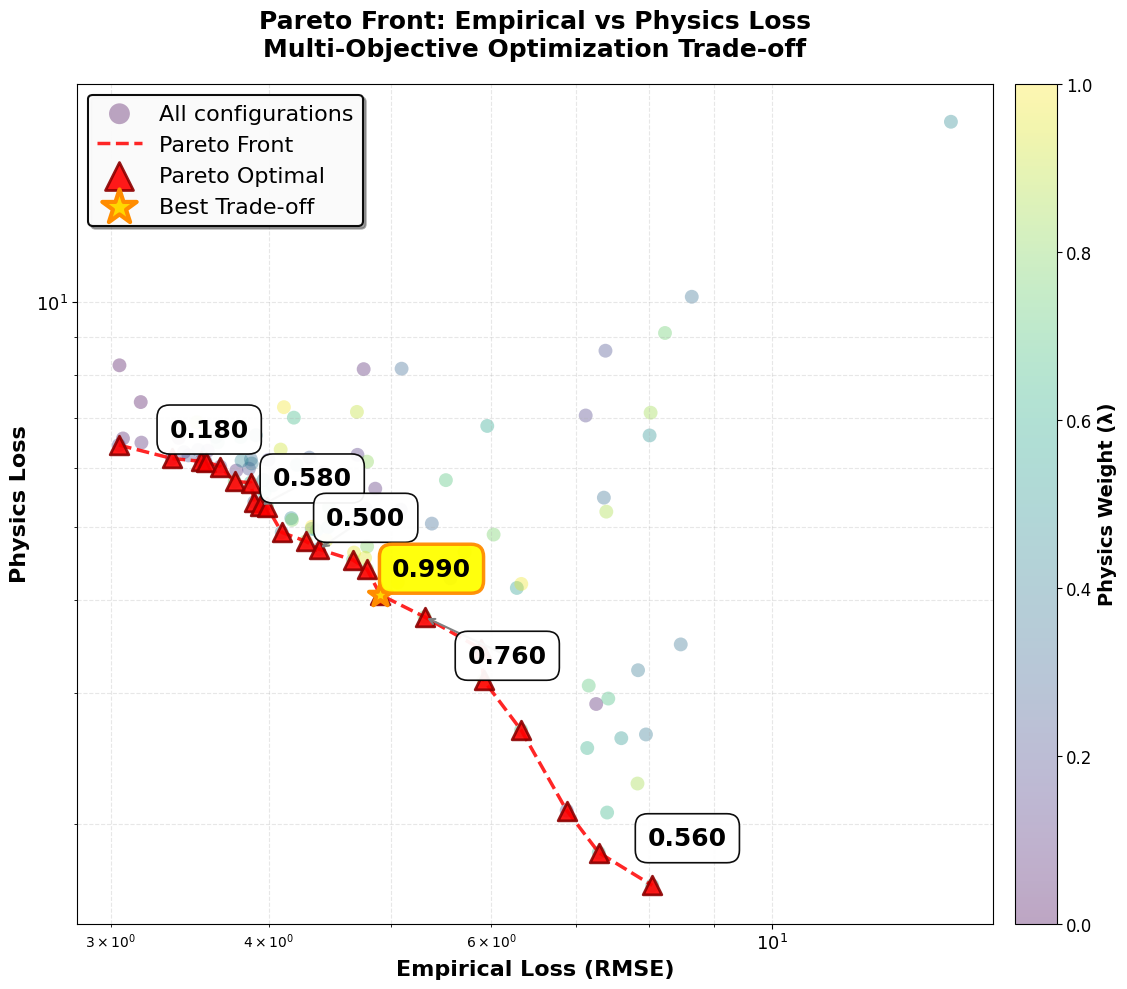

DONE


In [ ]:


# ============================================================================
# QUICK USAGE
# ============================================================================

if __name__ == "__main__":
    import os
    
    # Default paths
    results_path = '/home/exouser/git_test/multi-objective-pdbbind/pdbbind/grid_search/subset_100/grid_search_100_20260730-201158.json'
    output_path = '/home/exouser/git_test/multi-objective-pdbbind/plots/pareto_front_full_pdb.png'
    
    # Check if results exist
    if not os.path.exists(results_path):
        print(f"Error: Results not found at {results_path}")
        print("\nUsage:")
        print("  python plot_pareto_simple.py")
        print("\nOr with custom paths:")
        print("  python -c \"from plot_pareto_simple import plot_pareto_simple; "
              "plot_pareto_simple('my_results.json', 'my_plot.png')\"")
        exit(1)
    
    # Create output directory
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    print("="*70)
    print("PARETO FRONT PLOTTER")
    print("="*70)
    
    # Create plot
    plot_pareto_simple(results_path, output_path)
    
    print("="*70)
    print("DONE")
    print("="*70)
    